In [164]:
import importlib
import miaw
importlib.reload(miaw)
from miaw import FFNN
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.utils import check_random_state
from sklearn.metrics import accuracy_score


## Usage

In [3]:
# train-test data
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

random_state = check_random_state(0)
permutation = random_state.permutation(X.shape[0])
X = X[permutation]
y = y[permutation]
X = X.reshape((X.shape[0], -1))

encoder = OneHotEncoder(sparse_output=False, categories='auto')
y_encoded = encoder.fit_transform(y.reshape(-1, 1))

# train-test split
X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
print(X_train.shape, y_train.shape, X_val.shape, y_val.shape)

(56000, 784) (56000, 10) (14000, 784) (14000, 10)


In [4]:
# Random test sample from Kaggle
test_url = 'https://drive.google.com/uc?id=1VwGTcs1guwJTnUHKdOkMgDUtuW18DbEp'
test_df = pd.read_csv(test_url)

y_test = test_df["label"].values 
X_test = test_df.drop(columns=["label"]).values
print(X_test.shape, y_test.shape)

(10000, 784) (10000,)


## Pengaruh Depth dan Width

### Pengaruh Depth

In [ ]:
# Depth 0: No hidden layer
d0_model = FFNN([784,10], ['softmax'],loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')
d0_history = d0_model.fit(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.05, verbose=0)

Val accuracy: 89.30%, Test accuracy: 91.24%


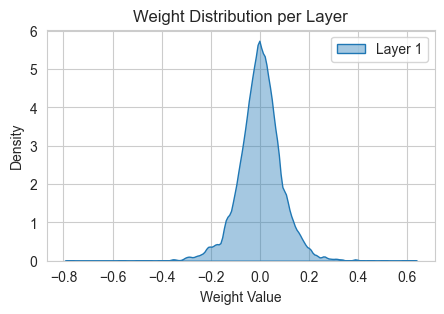

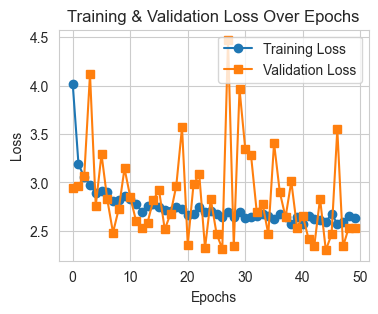

In [ ]:
d0_test_pred = d0_model.predict(X_test)
d0_val_pred = d0_model.predict(X_val)

y_val_decoded = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(d0_val_pred, y_val_decoded)
test_accuracy = accuracy_score(d0_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

d0_model.plot_weight_distribution([0])
d0_model.plot_loss_history(d0_history)

In [ ]:
# Depth 1: 1 hidden layer
d1_model = FFNN([784, 64, 10], ['relu', 'softmax'],loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')
d1_history = d1_model.fit(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.05, verbose=0)

Val accuracy: 93.28%, Test accuracy: 95.28%


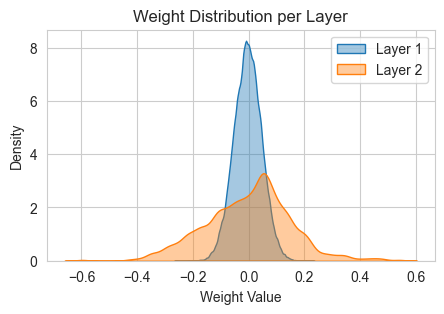

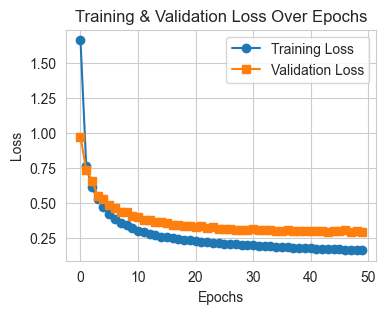

In [31]:
d1_test_pred = d1_model.predict(X_test)
d1_val_pred = d1_model.predict(X_val)

y_val_decoded = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(d1_val_pred, y_val_decoded)
test_accuracy = accuracy_score(d1_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

d1_model.plot_weight_distribution([0, 1])
d1_model.plot_loss_history(d1_history)

In [23]:
# Depth 2: 2 hidden layer
d2_model = FFNN([784, 64, 64, 10], ['relu', 'relu', 'softmax'], loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')

d2_history = d2_model.fit(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.05, verbose=0)

Val accuracy: 92.73%, Test accuracy: 94.87%


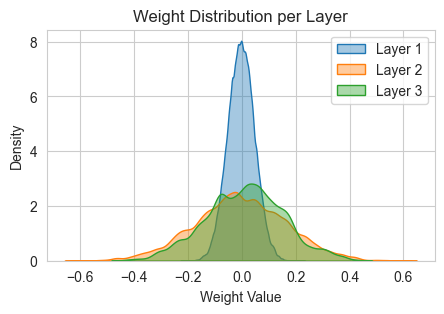

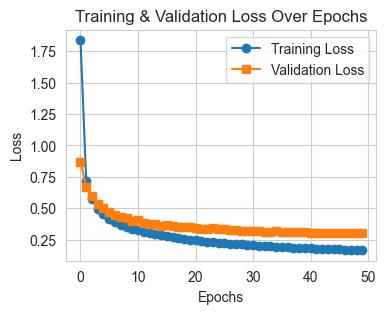

In [32]:
d2_test_pred = d2_model.predict(X_test)
d2_val_pred = d2_model.predict(X_val)

y_val_decoded = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(d2_val_pred, y_val_decoded)
test_accuracy = accuracy_score(d2_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

d2_model.plot_weight_distribution([0, 1, 2])
d2_model.plot_loss_history(d2_history)

In [ ]:
d0_model.save('./models/depth0.json')
d1_model.save('./models/depth1.json')
d2_model.save('./models/depth2.json')

In [34]:
d0_model.load('./models/depth0.json')
d1_model.load('./models/depth1.json')
d2_model.load('./models/depth2.json')

### Pengaruh Width

In [60]:
# Width 0: 3 neurons
w0_model = FFNN([784, 3, 10], ['relu', 'softmax'], loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')

w0_history = w0_model.fit(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.1, verbose=0)

Val accuracy: 11.13%, Test accuracy: 11.36%


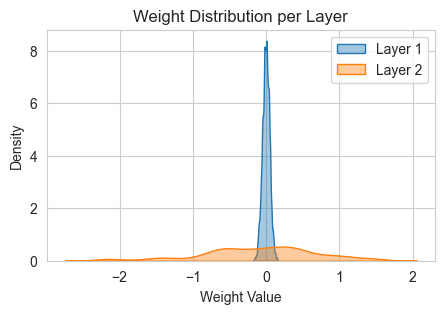

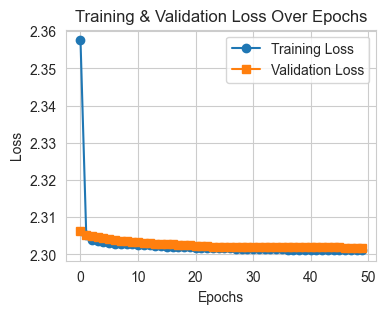

In [59]:
w0_test_pred = w0_model.predict(X_test)
w0_val_pred = w0_model.predict(X_val)

y_val_decoded = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(w0_val_pred, y_val_decoded)
test_accuracy = accuracy_score(w0_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

w0_model.plot_weight_distribution([0, 1])
w0_model.plot_loss_history(w0_history)


In [45]:
# Width 1: 24 neurons
w1_model = FFNN([784, 24, 10], ['relu', 'softmax'], loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')

w1_history = w1_model.fit(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.1, verbose=0)

Val accuracy: 74.51%, Test accuracy: 75.65%


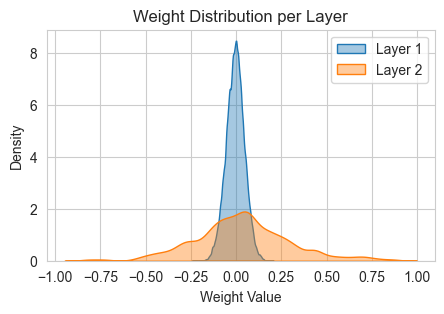

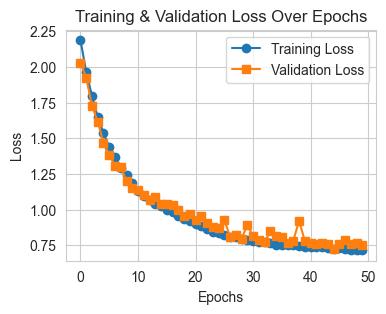

In [55]:
w1_test_pred = w1_model.predict(X_test)
w1_val_pred = w1_model.predict(X_val)

y_val_decoded = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(w1_val_pred, y_val_decoded)
test_accuracy = accuracy_score(w1_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

w1_model.plot_weight_distribution([0, 1])
w1_model.plot_loss_history(w1_history)

In [47]:
# Width 2: 64 neurons
w2_model = FFNN([784, 64, 10], ['relu', 'softmax'], loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')

w2_history = w2_model.fit(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.1, verbose=0)

Val accuracy: 93.22%, Test accuracy: 95.11%


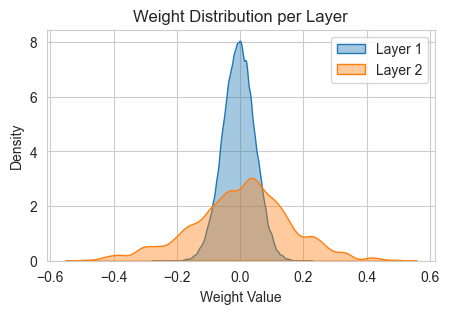

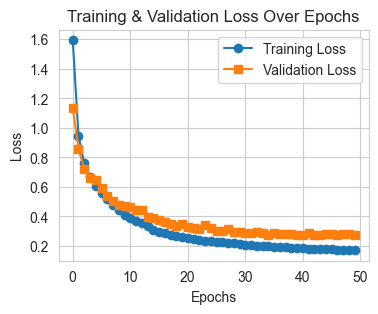

In [53]:
w2_test_pred = w2_model.predict(X_test)
w2_val_pred = w2_model.predict(X_val)

y_val_decoded = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(w2_val_pred, y_val_decoded)
test_accuracy = accuracy_score(w2_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

w2_model.plot_weight_distribution([0, 1])
w2_model.plot_loss_history(w2_history)

In [63]:
w0_model.save('./models/width0.json')
w1_model.save('./models/width1.json')
w2_model.save('./models/width2.json')

In [52]:
w0_model.load('./models/width0.json')
w1_model.load('./models/width1.json')
w2_model.load('./models/width2.json')

### Pengaruh Fungsi Aktivasi

In [113]:
# Relu
relu_model = FFNN([784, 64, 10], ['relu', 'softmax'], loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')

relu_history = relu_model.fit(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.05, verbose=0)

Val accuracy: 92.91%, Test accuracy: 94.53%


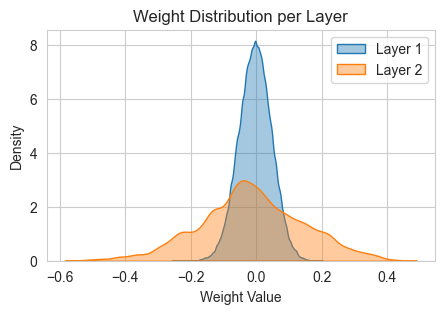

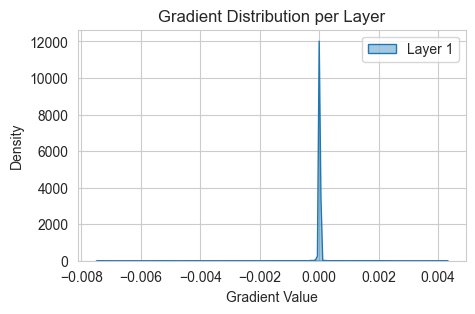

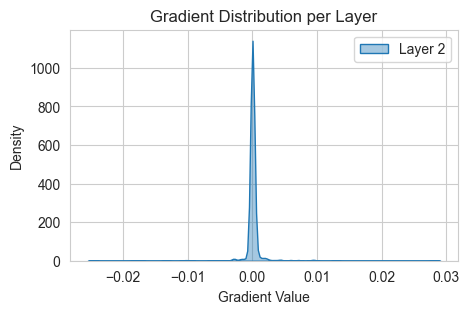

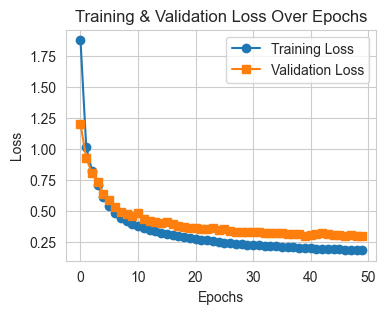

In [150]:
relu_test_pred = relu_model.predict(X_test)
relu_val_pred = relu_model.predict(X_val)

y_val_decoded = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(relu_val_pred, y_val_decoded)
test_accuracy = accuracy_score(relu_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

relu_model.plot_weight_distribution([0, 1])
relu_model.plot_gradient_distribution([0])
relu_gradients = relu_model.plot_gradient_distribution([1])
relu_model.plot_loss_history(relu_history)

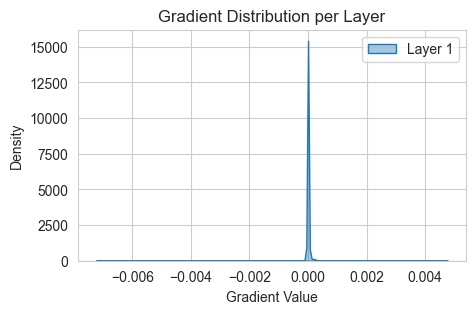

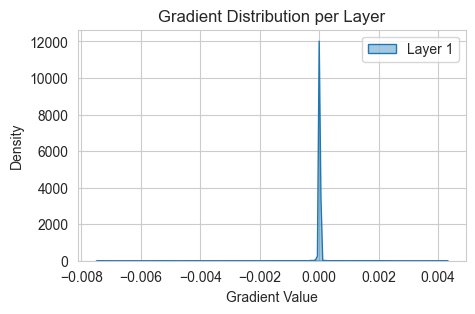

Sigmoid Gradients: [None]
ReLU Gradients: None


AttributeError: 'NoneType' object has no attribute 'size'

In [168]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get gradients and convert to NumPy arrays
sigmoid_gradients = np.array(sigmoid_model.plot_gradient_distribution([0])).flatten()
relu_gradients = relu_model.plot_gradient_distribution([0])

# Debugging: Check if gradients are empty
print(f"Sigmoid Gradients: {sigmoid_gradients}")  # Print first 10 values
print(f"ReLU Gradients: {relu_gradients}")

# Ensure non-empty data before plotting
if sigmoid_gradients.size == 0 or relu_gradients.size == 0:
    print("Error: One or both gradient arrays are empty. Check model outputs.")
else:
    # Plot the gradients
    plt.figure(figsize=(8, 5))
    sns.kdeplot(sigmoid_gradients, label="Sigmoid Layer 1", fill=True, alpha=0.4, bw_adjust=0.5)
    sns.kdeplot(relu_gradients, label="ReLU Layer 1", fill=True, alpha=0.4, bw_adjust=0.5)

    # Labels and Title
    plt.xlabel('Gradient Value')
    plt.ylabel('Density')
    plt.title('Gradient Distribution Comparison')
    plt.legend()
    plt.show()


In [123]:
# Sigmoid
sigmoid_model = FFNN([784, 64, 10], ['sigmoid', 'softmax'], loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')

sigmoid_history = sigmoid_model.fit(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.05, verbose=0)

Val accuracy: 90.91%, Test accuracy: 92.71%


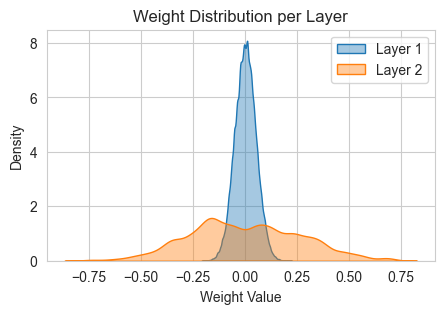

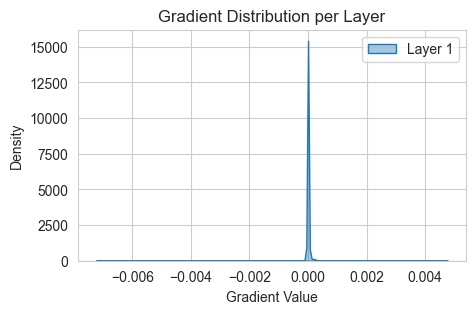

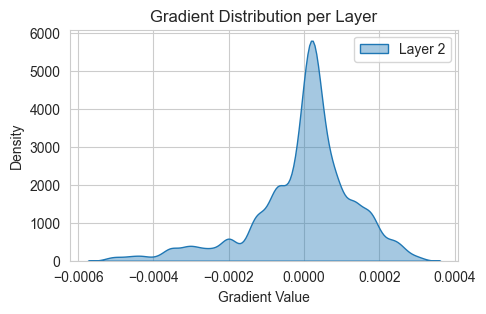

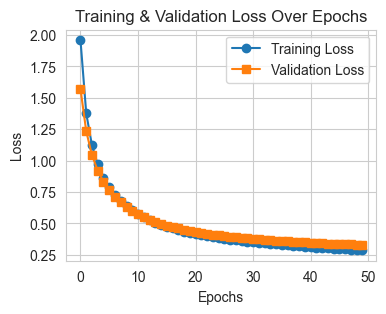

In [166]:
sigmoid_test_pred = sigmoid_model.predict(X_test)
sigmoid_val_pred = sigmoid_model.predict(X_val)

y_val_decoded = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(sigmoid_val_pred, y_val_decoded)
test_accuracy = accuracy_score(sigmoid_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

sigmoid_model.plot_weight_distribution([0, 1])
sigmoid_model.plot_gradient_distribution([0])
sigmoid_gradients = sigmoid_model.plot_gradient_distribution([1])
sigmoid_model.plot_loss_history(sigmoid_history)

In [118]:
# Tanh
tanh_model = FFNN([784, 64, 10], ['tanh', 'softmax'], loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')

tanh_history = tanh_model.fit(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.05, verbose=0)

Val accuracy: 92.74%, Test accuracy: 94.34%


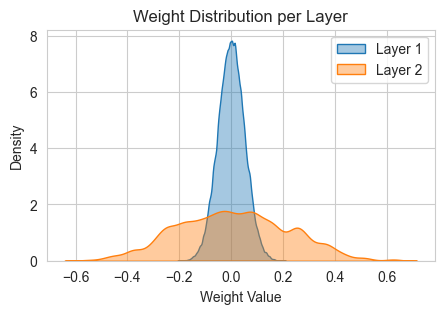

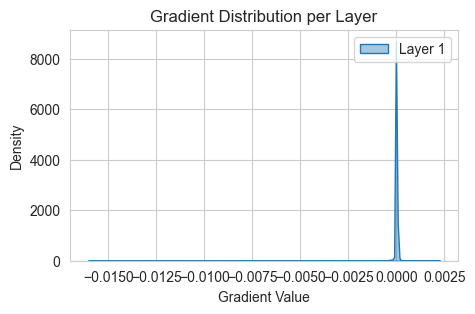

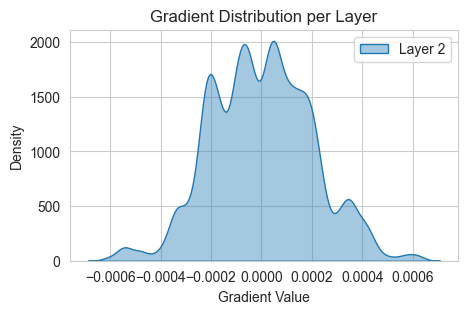

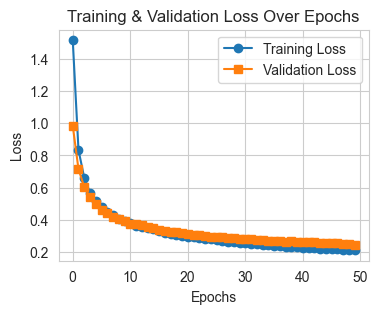

In [119]:
tanh_test_pred = tanh_model.predict(X_test)
tanh_val_pred = tanh_model.predict(X_val)

y_val_decoded = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(tanh_val_pred, y_val_decoded)
test_accuracy = accuracy_score(tanh_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

tanh_model.plot_weight_distribution([0, 1])
tanh_model.plot_gradient_distribution([0])
tanh_model.plot_gradient_distribution([1])
tanh_model.plot_loss_history(tanh_history)

In [122]:
# Linear
linear_model = FFNN([784, 64, 10], ['linear', 'softmax'], loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')

linear_history = linear_model.fit(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.05, verbose=0)

Val accuracy: 89.58%, Test accuracy: 91.14%


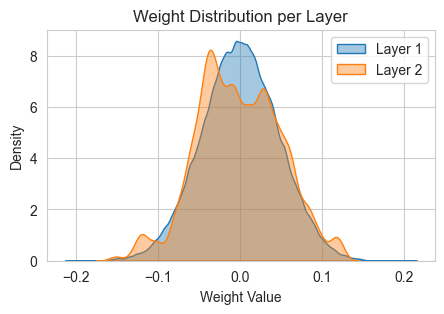

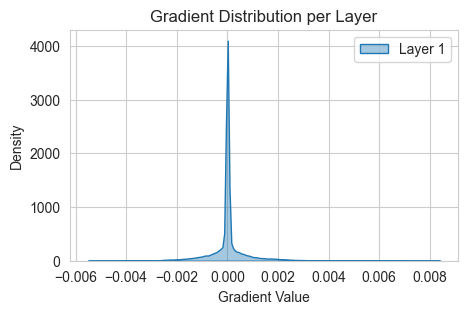

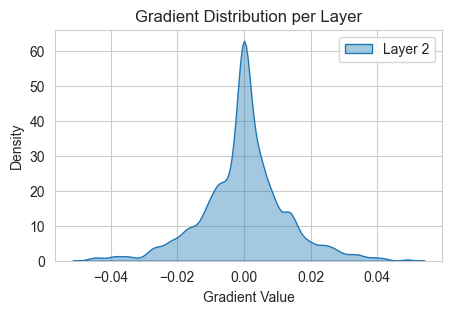

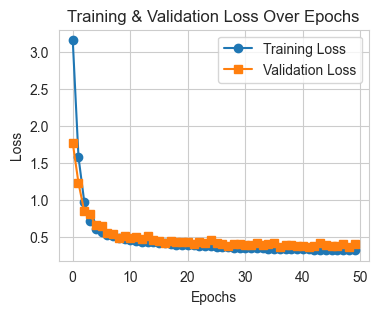

In [129]:
linear_test_pred = linear_model.predict(X_test)
linear_val_pred = linear_model.predict(X_val)

y_val_decoded = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(linear_val_pred, y_val_decoded)
test_accuracy = accuracy_score(linear_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

linear_model.plot_weight_distribution([0, 1])
linear_model.plot_gradient_distribution([0])
linear_model.plot_gradient_distribution([1])
linear_model.plot_loss_history(linear_history)

In [127]:
# Swish
swish_model = FFNN([784, 64, 10], ['swish', 'softmax'], loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')

swish_history = swish_model.fit(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.05, verbose=0)

Val accuracy: 92.24%, Test accuracy: 93.95%


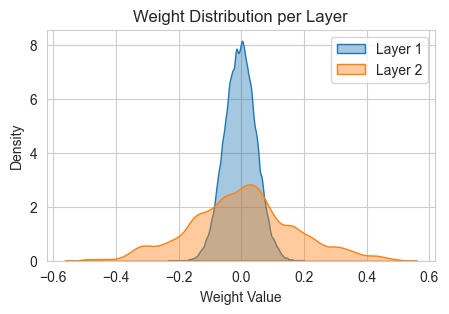

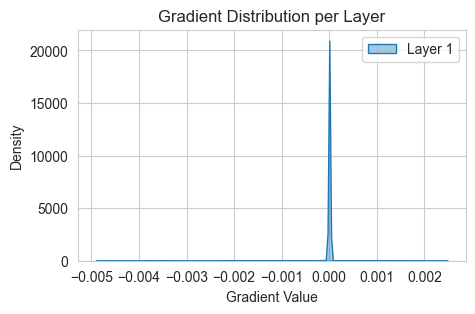

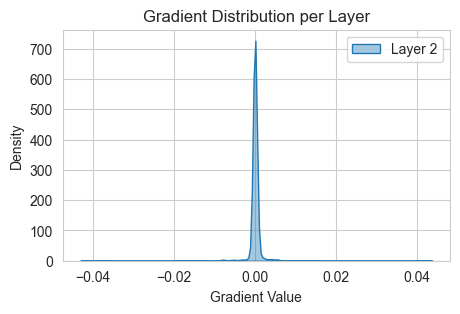

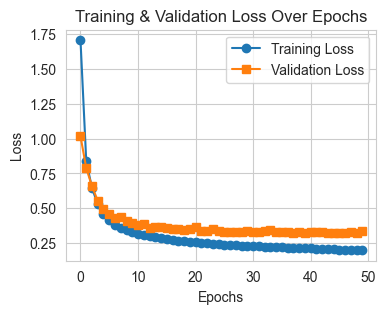

In [131]:
swish_test_pred = swish_model.predict(X_test)
swish_val_pred = swish_model.predict(X_val)

y_val_decoded = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(swish_val_pred, y_val_decoded)
test_accuracy = accuracy_score(swish_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

swish_model.plot_weight_distribution([0, 1])
swish_model.plot_gradient_distribution([0])
swish_model.plot_gradient_distribution([1])
swish_model.plot_loss_history(swish_history)

In [132]:
# Swish
leaky_relu_model = FFNN([784, 64, 10], ['leaky_relu', 'softmax'], loss_function='cce', use_rmsnorm=False, reg_type="l2", weight_init='he')

leaky_relu_history = leaky_relu_model.fit(X_train, y_train, X_val, y_val, epochs=50, batch_size=64, lr=0.05, verbose=0)

Val accuracy: 93.46%, Test accuracy: 94.85%


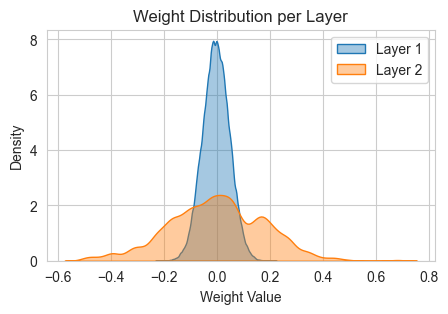

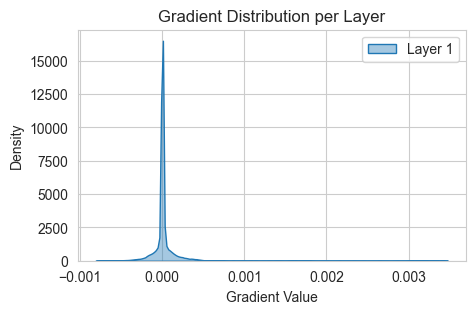

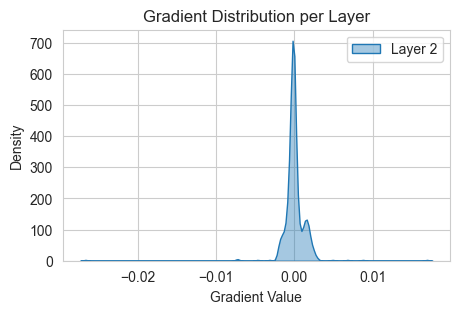

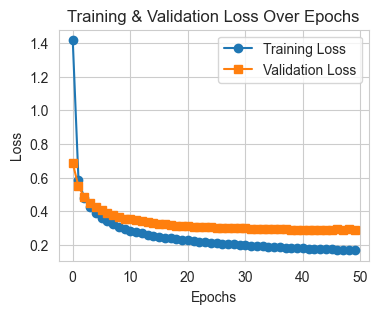

In [134]:
leaky_relu_test_pred = leaky_relu_model.predict(X_test)
leaky_relu_val_pred = leaky_relu_model.predict(X_val)

y_val_decoded = np.argmax(y_val, axis=1)

val_accuracy = accuracy_score(leaky_relu_val_pred, y_val_decoded)
test_accuracy = accuracy_score(leaky_relu_test_pred, y_test)
print(f"Val accuracy: {val_accuracy * 100:.2f}%, Test accuracy: {test_accuracy * 100:.2f}%")

leaky_relu_model.plot_weight_distribution([0, 1])
leaky_relu_model.plot_gradient_distribution([0])
leaky_relu_model.plot_gradient_distribution([1])
leaky_relu_model.plot_loss_history(leaky_relu_history)

In [146]:
relu_model.save('./models/relu.json')
sigmoid_model.save('./models/sigmoid.json')
tanh_model.save('./models/tanh.json')
linear_model.save('./models/linear.json')
swish_model.save('./models/swish.json')
leaky_relu_model.save('./models/leaky_relu.json')

In [ ]:
relu_model = FFNN.load('./models/relu.json')
sigmoid_model = FFNN.load('./models/sigmoid.json')

# relu_model.load('./models/relu.json')
# sigmoid_model.load('./models/sigmoid.json')
tanh_model.load('./models/tanh.json')
linear_model.load('./models/linear.json')
swish_model.load('./models/swish.json')
leaky_relu_model.load('./models/leaky_relu.json')

NameError: name 'sigmoid_model' is not defined